Dados prontos. Período: 1996-09-30 a 2024-12-31

TESTES DE DIAGNÓSTICO
Autocorrelação (Breusch-Godfrey): p-valor = 0.0000
Heterocedasticidade (White): p-valor = 0.6748

RESULTADOS FINAIS DO MODELO 1 (HAC + DUMMIES)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     3.841
Date:                Sun, 10 May 2026   Prob (F-statistic):             0.0117
Time:                        15:47:03   Log-Likelihood:                -140.14
No. Observations:                 114   AIC:                             288.3
Df Residuals:                     110   BIC:                             299.2
Df Model:                           3                                         
Covariance Type:                  HAC                                     

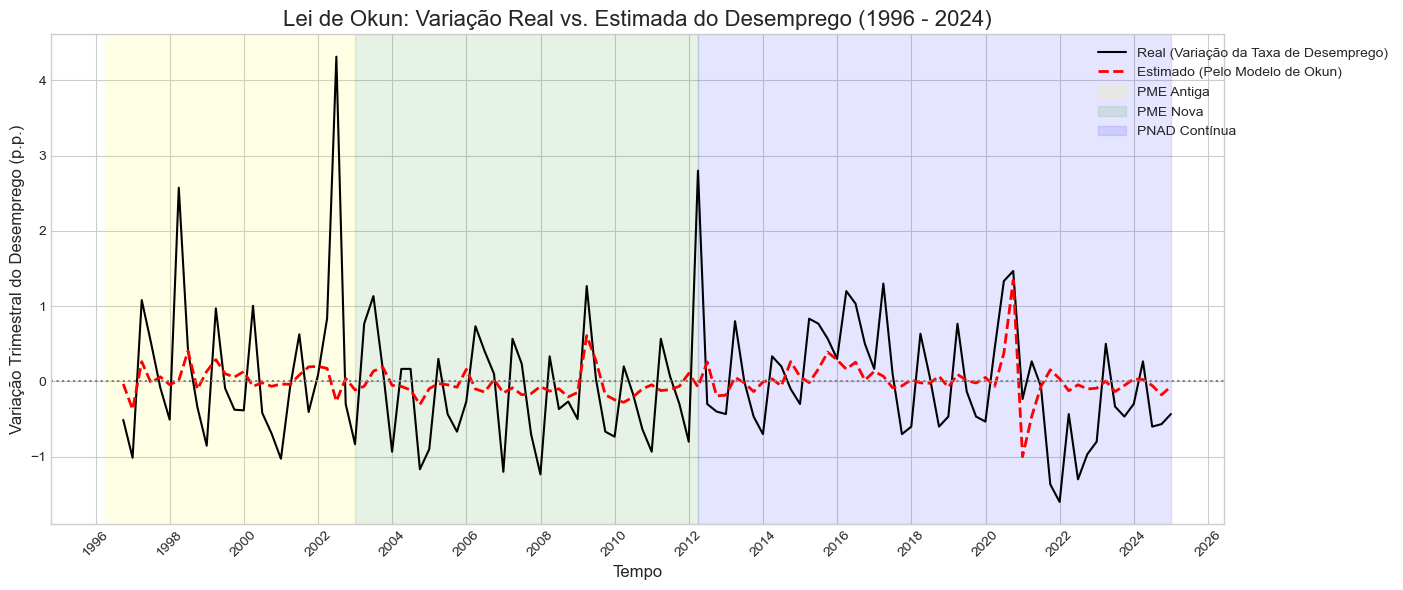

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
try:
    pib_df = pd.read_pickle('../dados/pib_tratado.pkl')
    desemprego_df = pd.read_pickle('../dados/desemprego_tratado.pkl')

    if 'desemprego' in desemprego_df.columns:
        desemprego_df.rename(columns={'desemprego': 'u_t'}, inplace=True)

    df_model = pib_df.join(desemprego_df, how='inner')
    df_model = df_model[df_model.index <= '2024-12-31'].copy()

    # Diferenças e Defasagens
    df_model['delta_u_t'] = df_model['u_t'].diff()
    df_model['crescimento_pib'] = df_model['ln_pib'].diff() * 100
    df_model['crescimento_pib_lag1'] = df_model['crescimento_pib'].shift(1)

    # CRIANDO AS DUMMIES METODOLÓGICAS
    # drop_first=True remove a primeira (PME_Antiga), que vira a categoria "base" (intercepto padrão)
    dummies = pd.get_dummies(df_model['metodologia'], prefix='metodo', drop_first=True).astype(float)
    df_model = pd.concat([df_model, dummies], axis=1)

    df_model.dropna(inplace=True)

    print(f"Dados prontos. Período: {df_model.index.min().date()} a {df_model.index.max().date()}")
    
except FileNotFoundError:
    print("Erro: Arquivos .pkl não encontrados.")

# --- 2. ESTIMAÇÃO DO MODELO COM DUMMIES ---
Y = df_model['delta_u_t']
# Inclui o PIB defasado e as Dummies
cols_explicativas = ['crescimento_pib_lag1'] + list(dummies.columns)
X = sm.add_constant(df_model[cols_explicativas])

modelo_ols = sm.OLS(Y, X).fit()

# --- 3. TESTES DE DIAGNÓSTICO E CORREÇÃO HAC ---
print("\n" + "="*60)
print("TESTES DE DIAGNÓSTICO")
print("="*60)
bg_test = acorr_breusch_godfrey(modelo_ols, nlags=4)
print(f"Autocorrelação (Breusch-Godfrey): p-valor = {bg_test[1]:.4f}")

white_test = het_white(modelo_ols.resid, modelo_ols.model.exog)
print(f"Heterocedasticidade (White): p-valor = {white_test[1]:.4f}")

# Estimação final robusta (HAC) recomendada em séries temporais
modelo_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print("\n" + "="*60)
print("RESULTADOS FINAIS DO MODELO 1 (HAC + DUMMIES)")
print("="*60)
print(modelo_hac.summary())

# --- 4. VISUALIZAÇÃO: REAL VS ESTIMADO ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

# Plotar os valores reais
ax.plot(df_model.index, Y, label='Real (Variação da Taxa de Desemprego)', color='black', linewidth=1.5)

# Plotar os valores estimados (fitted values) do modelo
ax.plot(df_model.index, modelo_hac.fittedvalues, label='Estimado (Pelo Modelo de Okun)', color='red', linestyle='--', linewidth=2)

ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Lei de Okun: Variação Real vs. Estimada do Desemprego (1996 - 2024)', fontsize=16)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Tempo', fontsize=12)

# Fundo sombreado para as metodologias
ax.axvspan('1996-03-31', '2002-12-31', color='yellow', alpha=0.1, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green', alpha=0.1, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='blue', alpha=0.1, label='PNAD Contínua')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Ajuste da legenda para fora do gráfico se ficar muito poluído, mas por padrão na melhor localização
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()


Modelo 1 (Primeira Diferença) Ajustado com Dummies de Intervenção e Metodologia
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     1248.
Date:                Sun, 10 May 2026   Prob (F-statistic):           8.87e-89
Time:                        15:47:03   Log-Likelihood:                -103.37
No. Observations:                 114   AIC:                             220.7
Df Residuals:                     107   BIC:                             239.9
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '


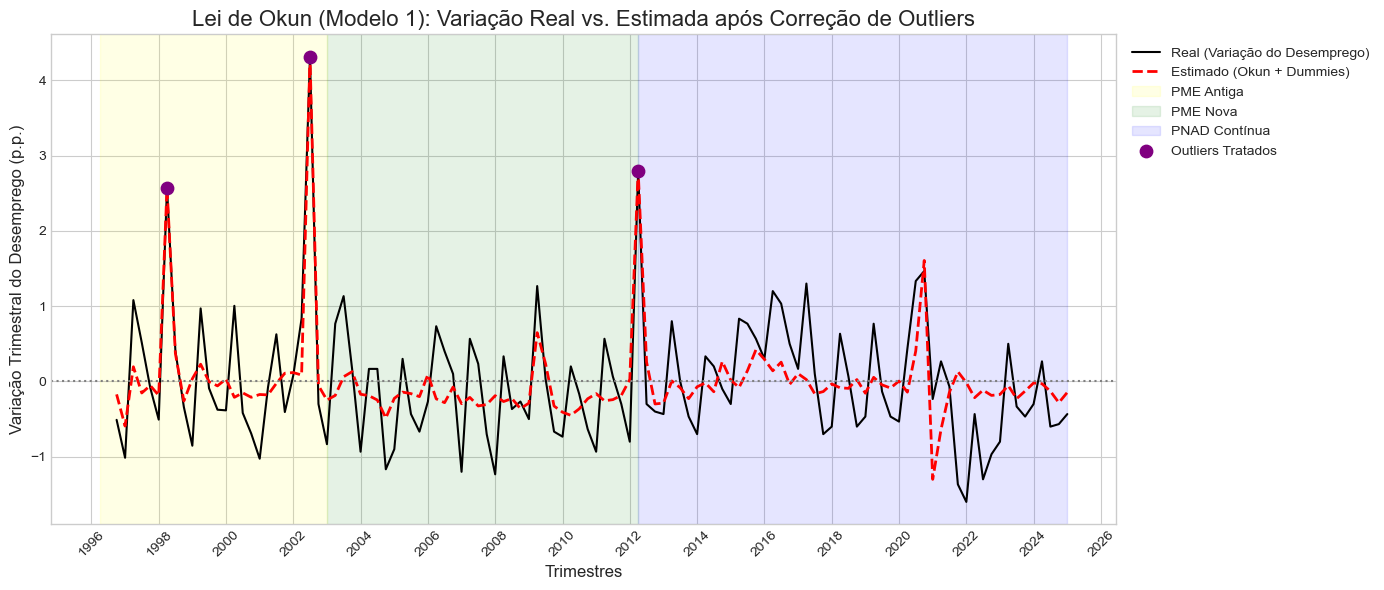

In [26]:
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

# ==============================================================================
# FASE 2: RE-ESTIMAÇÃO DO MODELO 1 COM DUMMIES DE OUTLIERS (NOVA CÉLULA)
# ==============================================================================

# 1. Usaremos o df_model que já existe no notebook atual
df_modelo1 = df_model.copy()

# 2. Criar as Pulse Dummies (para os outliers exatos identificados na Fase 1.8)
df_modelo1['d_1998_t1'] = (df_modelo1.index == '1998-03-31').astype(float)
df_modelo1['d_2002_t2'] = (df_modelo1.index == '2002-06-30').astype(float)
df_modelo1['d_2012_t1'] = (df_modelo1.index == '2012-03-31').astype(float)

# 3. Definir as variáveis Independentes (X) e a Dependente (Y)
# Note que df_model já possui 'metodo_PME_Nova' e 'metodo_PNADc' criadas na célula anterior
X_vars = ['crescimento_pib_lag1', 'metodo_PME_Nova', 'metodo_PNADc', 'd_1998_t1', 'd_2002_t2', 'd_2012_t1']
X = sm.add_constant(df_modelo1[X_vars]) #com constante
#X = df_model[cols_explicativas] #sem contante
Y = df_modelo1['delta_u_t']

# 4. Re-estimar o Modelo OLS (já aplicando a correção HAC que sabemos ser necessária)
modelo1_ajustado = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print("===============================================================================")
print("Modelo 1 (Primeira Diferença) Ajustado com Dummies de Intervenção e Metodologia")
print("===============================================================================")
print(modelo1_ajustado.summary())

# 5. Novo Diagnóstico de Normalidade (Teste de Jarque-Bera)
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(modelo1_ajustado.resid)

print("\n" + "="*65)
print("--- Diagnóstico Pós-Dummies: Normalidade dos Resíduos ---")
print(f"Estatística Jarque-Bera: {jb_stat:.4f}")
print(f"P-valor: {jb_pvalue:.4f}")

if jb_pvalue > 0.05:
    print("=> Conclusão: NÃO REJEITA H0. O modelo foi curado e os resíduos AGORA APRESENTAM distribuição normal!")
else:
    print("=> Conclusão: Rejeita H0. Os resíduos continuam não-normais (p-valor < 0.05).")

# --- 6. VISUALIZAÇÃO: REAL VS ESTIMADO (PÓS-DUMMIES) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

# Plotar os valores reais
ax.plot(df_modelo1.index, Y, label='Real (Variação do Desemprego)', color='black', linewidth=1.5)

# Plotar os valores estimados (fitted values) do modelo COM as dummies
ax.plot(df_modelo1.index, modelo1_ajustado.fittedvalues, label='Estimado (Okun + Dummies)', color='red', linestyle='--', linewidth=2)

ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Lei de Okun (Modelo 1): Variação Real vs. Estimada após Correção de Outliers', fontsize=16)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)

# Fundo sombreado para as metodologias
ax.axvspan('1996-03-31', '2002-12-31', color='yellow', alpha=0.1, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green', alpha=0.1, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='blue', alpha=0.1, label='PNAD Contínua')

# Destacar os pontos onde aplicamos as pulse dummies
outliers_dates = pd.to_datetime(['1998-03-31', '2002-06-30', '2012-03-31'])
ax.scatter(outliers_dates, Y.loc[outliers_dates], color='purple', s=80, zorder=5, label='Outliers Tratados')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Colocando a legenda um pouco para fora para não tampar a linha
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()


Modelo Clássico da Lei de Okun: Apenas Crescimento do PIB (Lag 1)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     10.33
Date:                Sun, 10 May 2026   Prob (F-statistic):            0.00171
Time:                        15:47:04   Log-Likelihood:                -140.20
No. Observations:                 114   AIC:                             284.4
Df Residuals:                     112   BIC:                             289.9
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

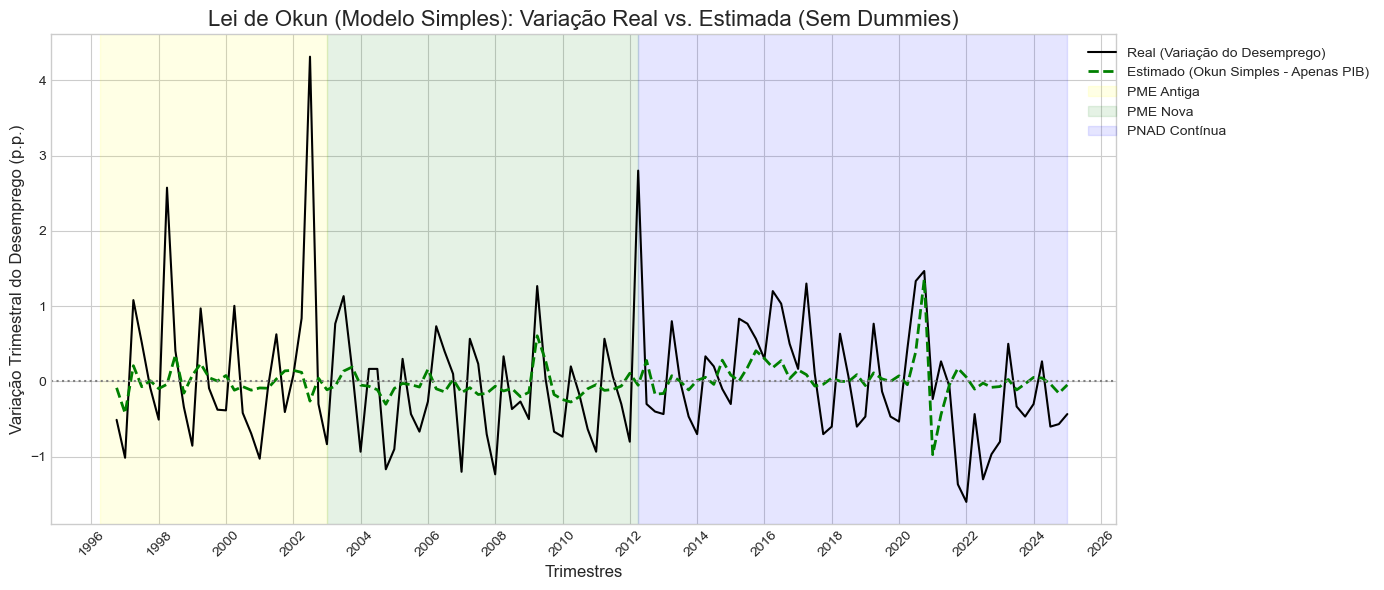

In [27]:
import statsmodels.api as sm

# ==============================================================================
# ESTIMAÇÃO DO MODELO SIMPLIFICADO: APENAS PIB (LAG 1) SEM DUMMIES
# ==============================================================================

# 1. Preparar os dados apenas com a variável dependente e a explicativa principal
df_simples = df_model[['delta_u_t', 'crescimento_pib_lag1']].dropna()

# 2. Definir X (Variável Independente + Constante) e Y (Variável Dependente)
X_simples = sm.add_constant(df_simples['crescimento_pib_lag1']) #com constante
#X_simples = df_simples['crescimento_pib_lag1'] #sem constante
Y_simples = df_simples['delta_u_t']

# 3. Estimar o modelo OLS 
# (Mantemos a correção HAC de Newey-West pois já sabemos que a série tem autocorrelação)
modelo_simples = sm.OLS(Y_simples, X_simples).fit(cov_type='HAC', cov_kwds={'maxlags': 4})


# 4. Exibir os resultados
print("===============================================================================")
print("Modelo Clássico da Lei de Okun: Apenas Crescimento do PIB (Lag 1)")
print("===============================================================================")
print(modelo_simples.summary())



# --- VISUALIZAÇÃO: REAL VS ESTIMADO (MODELO SIMPLIFICADO SEM DUMMIES) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

# Plotar os valores reais
ax.plot(df_simples.index, Y_simples, label='Real (Variação do Desemprego)', color='black', linewidth=1.5)

# Plotar os valores estimados (fitted values) do modelo simples
ax.plot(df_simples.index, modelo_simples.fittedvalues, label='Estimado (Okun Simples - Apenas PIB)', color='green', linestyle='--', linewidth=2)

ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Lei de Okun (Modelo Simples): Variação Real vs. Estimada (Sem Dummies)', fontsize=16)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)

# Fundo sombreado para as metodologias
ax.axvspan('1996-03-31', '2002-12-31', color='yellow', alpha=0.1, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green', alpha=0.1, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='blue', alpha=0.1, label='PNAD Contínua')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Colocando a legenda um pouco para fora
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()


Resultados do Modelo 1 Ajustado (Okun + Outliers)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     1291.
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.31e-76
Time:                        15:47:05   Log-Likelihood:                -103.41
No. Observations:                 114   AIC:                             216.8
Df Residuals:                     109   BIC:                             230.5
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '


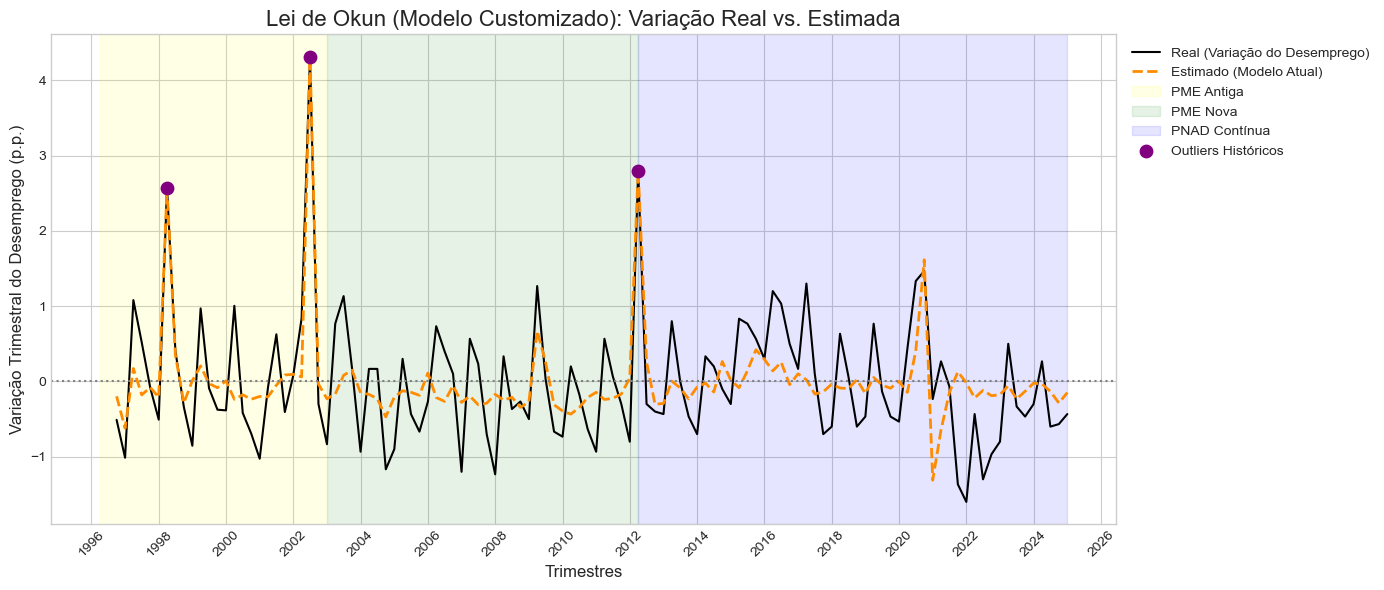

In [28]:
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

# ==============================================================================
# FASE 2: RE-ESTIMAÇÃO DO MODELO 1 (CONTROLE DE DUMMIES E CONSTANTE)
# ==============================================================================

# 1. Preparando o DataFrame e as pulse dummies dos outliers
df_modelo1 = df_model.copy()
df_modelo1['d_1998_t1'] = (df_modelo1.index == '1998-03-31').astype(float)
df_modelo1['d_2002_t2'] = (df_modelo1.index == '2002-06-30').astype(float)
df_modelo1['d_2012_t1'] = (df_modelo1.index == '2012-03-31').astype(float)

# ------------------------------------------------------------------------------
# 2. ESCOLHA DE VARIÁVEIS EXPLICATIVAS (LIGA / DESLIGA)
# ------------------------------------------------------------------------------

# OPÇÃO 1: COM as dummies metodológicas (PME Nova e PNADc)
# X_vars = ['crescimento_pib_lag1', 'metodo_PME_Nova', 'metodo_PNADc', 'd_1998_t1', 'd_2002_t2', 'd_2012_t1']

# OPÇÃO 2: SEM as dummies metodológicas (Apenas PIB e choques) - ATIVA AGORA
X_vars = ['crescimento_pib_lag1', 'd_1998_t1', 'd_2002_t2', 'd_2012_t1']


# ------------------------------------------------------------------------------
# 3. DEFINIÇÃO DO MODELO (COM / SEM CONSTANTE)
# ------------------------------------------------------------------------------
Y = df_modelo1['delta_u_t']

# PARA TER CONSTANTE (Ativa agora)
X = sm.add_constant(df_modelo1[X_vars])

# PARA NÃO TER CONSTANTE (Descomente a linha abaixo e comente a anterior)
#X = df_modelo1[X_vars]


# 4. Estimação do Modelo OLS com Correção HAC
modelo1_ajustado = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# 5. Exibição dos Resultados
print("===============================================================================")
print("Resultados do Modelo 1 Ajustado (Okun + Outliers)")
print("===============================================================================")
print(modelo1_ajustado.summary())

# Teste de Normalidade Rápido
jb_stat, jb_pvalue, _, _ = jarque_bera(modelo1_ajustado.resid)
print(f"\n=> Teste Jarque-Bera (Normalidade dos Resíduos): P-valor = {jb_pvalue:.4f}")


# ==============================================================================
# VISUALIZAÇÃO: REAL VS ESTIMADO (MODELO CUSTOMIZADO)
# ==============================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

# Plotar os valores reais
ax.plot(df_modelo1.index, Y, label='Real (Variação do Desemprego)', color='black', linewidth=1.5)

# Plotar os valores estimados (fitted values) do modelo que você acabou de rodar
ax.plot(df_modelo1.index, modelo1_ajustado.fittedvalues, label='Estimado (Modelo Atual)', color='darkorange', linestyle='--', linewidth=2)

ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Lei de Okun (Modelo Customizado): Variação Real vs. Estimada', fontsize=16)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)

# Fundo sombreado para as metodologias de pesquisa (para referência)
ax.axvspan('1996-03-31', '2002-12-31', color='yellow', alpha=0.1, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green', alpha=0.1, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='blue', alpha=0.1, label='PNAD Contínua')

# Destacar os pontos dos outliers (roxo)
outliers_dates = pd.to_datetime(['1998-03-31', '2002-06-30', '2012-03-31'])
ax.scatter(outliers_dates, Y.loc[outliers_dates], color='purple', s=80, zorder=5, label='Outliers Históricos')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Colocando a legenda um pouco para fora para não cobrir o gráfico
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()


In [29]:
# --- CÁLCULO DA TAXA NEUTRA DE CRESCIMENTO DO PIB ---

# Certifique-se de que a célula que define 'modelo1_ajustado' foi executada.

# 1. Extrair os coeficientes do modelo
try:
    beta_0 = modelo1_ajustado.params['const']
    beta_1 = modelo1_ajustado.params['crescimento_pib_lag1']

    # 2. Calcular a taxa neutra
    taxa_neutra_trimestral = - (beta_0 / beta_1)

    # 3. Calcular a taxa anualizada (aproximada)
    # (1 + taxa_trimestral)^4 - 1
    taxa_neutra_anual = ((1 + taxa_neutra_trimestral / 100)**4 - 1) * 100

    print("="*65)
    print("Cálculo da Taxa Neutra de Crescimento para Estabilizar o Desemprego")
    print("="*65)
    print(f"Equação: Δu_t = {beta_0:.4f} + ({beta_1:.4f}) * crescimento_pib_t-1")
    print(f"Cálculo: Taxa Neutra = - ({beta_0:.4f} / {beta_1:.4f})")
    print("-" * 65)
    print(f"Resultado (Trimestral): {taxa_neutra_trimestral:.2f}%")
    print(f"Resultado (Anualizado): {taxa_neutra_anual:.2f}%")
    print("\nInterpretação: A economia brasileira precisa crescer aproximadamente "
          f"{taxa_neutra_anual:.2f}% ao ano apenas para que a taxa de desemprego não aumente.")

except NameError:
    print("Erro: O objeto 'modelo1_ajustado' não foi encontrado. "
          "Por favor, execute a célula do modelo anterior primeiro.")



Cálculo da Taxa Neutra de Crescimento para Estabilizar o Desemprego
Equação: Δu_t = 0.0064 + (-0.1729) * crescimento_pib_t-1
Cálculo: Taxa Neutra = - (0.0064 / -0.1729)
-----------------------------------------------------------------
Resultado (Trimestral): 0.04%
Resultado (Anualizado): 0.15%

Interpretação: A economia brasileira precisa crescer aproximadamente 0.15% ao ano apenas para que a taxa de desemprego não aumente.


Valores ANTES da Interpolação:
1998-03-31    2.573333
2002-06-30    4.313000
2012-03-31    2.800000
Name: delta_u_t, dtype: float64

Valores DEPOIS da Interpolação:
1998-03-31   -0.052523
2002-06-30    0.272444
2012-03-31   -0.550000
Name: delta_u_t, dtype: float64

Modelo da Lei de Okun: Série Interpolada (Sem Dummies)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     16.61
Date:                Sun, 10 May 2026   Prob (F-statistic):           8.62e-05
Time:                        15:47:05   Log-Likelihood:                -104.29
No. Observations:                 114   AIC:                             212.6
Df Residuals:                     112   BIC:                             218.0
Df Model:                           1         

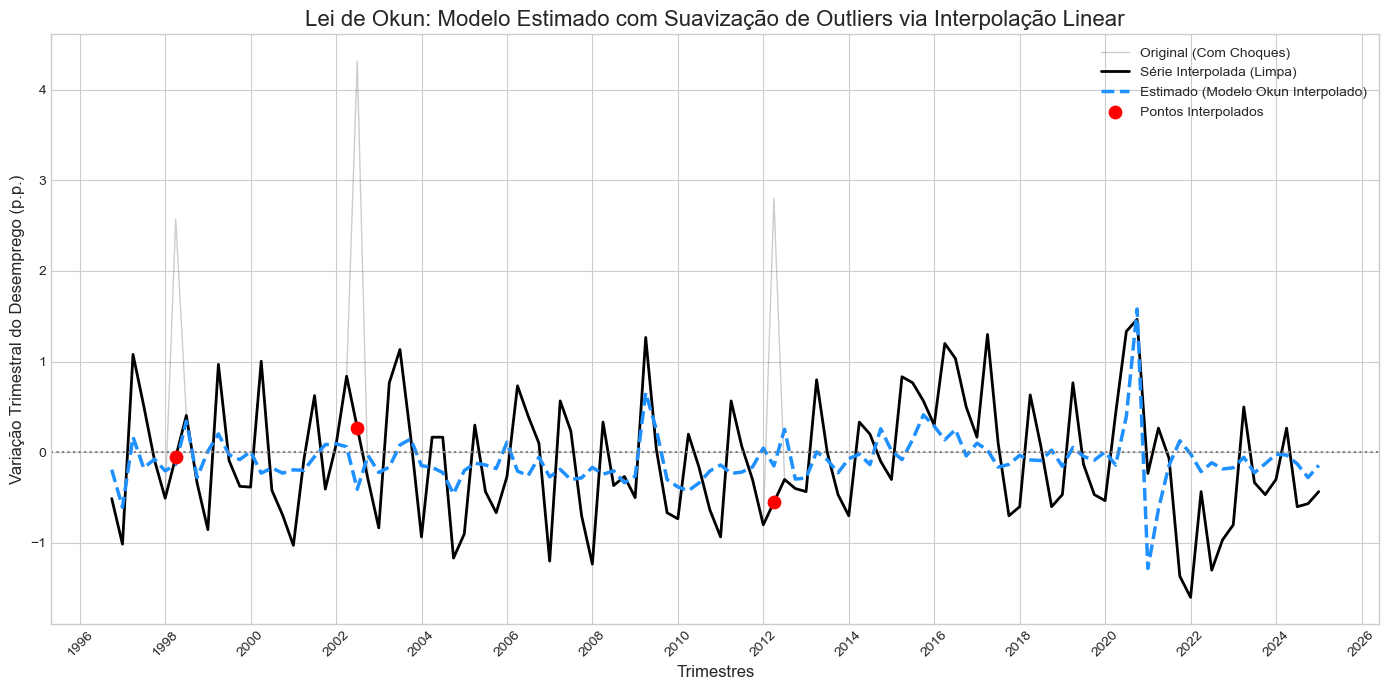

Cálculo da Nova Taxa Neutra de Crescimento (Modelo Interpolado)
Equação: Δu_t = 0.0075 + (-0.1690) * crescimento_pib_t-1
Taxa Neutra (Trimestral): 0.04%
Taxa Neutra (Anualizada): 0.18%


In [30]:
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ==============================================================================
# FASE 3: MODELO DA LEI DE OKUN COM INTERPOLAÇÃO DOS OUTLIERS
# ==============================================================================

# 1. Fazer uma cópia do DataFrame original para não alterar os dados base
df_interp = df_model.copy()

# 2. Definir as datas dos outliers que queremos suavizar
# Incluímos 2012-T1 (mudança IBGE) para limpar o salto artificial da série
datas_outliers = pd.to_datetime(['1998-03-31', '2002-06-30', '2012-03-31'])

print("===============================================================================")
print("Valores ANTES da Interpolação:")
print(df_interp.loc[datas_outliers, 'delta_u_t'])

# 3. Transformar os valores desses pontos em NaN na série de Variação do Desemprego
df_interp.loc[datas_outliers, 'delta_u_t'] = np.nan

# 4. Aplicar a interpolação linear para preencher os NaNs
# O método 'time' usa o índice de datas para calcular a distância correta entre os pontos
df_interp['delta_u_t'] = df_interp['delta_u_t'].interpolate(method='time')

print("\nValores DEPOIS da Interpolação:")
print(df_interp.loc[datas_outliers, 'delta_u_t'])
print("===============================================================================\n")

# 5. Definir as variáveis para o Modelo OLS (Apenas PIB defasado e Constante)
Y_interp = df_interp['delta_u_t']
X_interp = sm.add_constant(df_interp['crescimento_pib_lag1'])

# 6. Estimar o Modelo OLS com a correção HAC (Newey-West)
modelo_interp = sm.OLS(Y_interp, X_interp).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# 7. Exibir os resultados
print("===============================================================================")
print("Modelo da Lei de Okun: Série Interpolada (Sem Dummies)")
print("===============================================================================")
print(modelo_interp.summary())

# 8. Teste de Normalidade dos Resíduos
jb_stat, jb_pvalue, _, _ = jarque_bera(modelo_interp.resid)
print(f"\n=> Teste Jarque-Bera (Normalidade dos Resíduos): P-valor = {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print("=> Conclusão: NÃO REJEITA H0. Os resíduos apresentam distribuição normal!")
else:
    print("=> Conclusão: Rejeita H0. Os resíduos ainda são não-normais (p-valor < 0.05).")

# ==============================================================================
# VISUALIZAÇÃO: SÉRIE ORIGINAL VS SÉRIE INTERPOLADA E PREVISÃO
# ==============================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# Plotar a série real original (apenas os pontos, transparente, para referência)
ax.plot(df_model.index, df_model['delta_u_t'], label='Original (Com Choques)', color='gray', linestyle='-', alpha=0.4, linewidth=1)

# Plotar a série suavizada (interpolada)
ax.plot(df_interp.index, Y_interp, label='Série Interpolada (Limpa)', color='black', linewidth=2)

# Plotar os valores previstos pelo novo modelo
ax.plot(df_interp.index, modelo_interp.fittedvalues, label='Estimado (Modelo Okun Interpolado)', color='dodgerblue', linestyle='--', linewidth=2.5)

# Marcar os pontos que foram interpolados
ax.scatter(datas_outliers, Y_interp.loc[datas_outliers], color='red', s=80, zorder=5, label='Pontos Interpolados')

ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Lei de Okun: Modelo Estimado com Suavização de Outliers via Interpolação Linear', fontsize=16)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Legenda
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==============================================================================
# NOVO CÁLCULO DA TAXA NEUTRA
# ==============================================================================
beta_0_int = modelo_interp.params['const']
beta_1_int = modelo_interp.params['crescimento_pib_lag1']

taxa_neutra_trimestral_int = - (beta_0_int / beta_1_int)
taxa_neutra_anual_int = ((1 + taxa_neutra_trimestral_int / 100)**4 - 1) * 100

print("===============================================================================")
print("Cálculo da Nova Taxa Neutra de Crescimento (Modelo Interpolado)")
print("===============================================================================")
print(f"Equação: Δu_t = {beta_0_int:.4f} + ({beta_1_int:.4f}) * crescimento_pib_t-1")
print(f"Taxa Neutra (Trimestral): {taxa_neutra_trimestral_int:.2f}%")
print(f"Taxa Neutra (Anualizada): {taxa_neutra_anual_int:.2f}%")

TABELA COMPARATIVA — 4 MODELOS (Lei de Okun, Primeira Diferença, HAC)
Modelo                                             β₁   p(β₁)   R²Aj        JB        BG     White
--------------------------------------------------------------------------------
A: Dummies 1998+2002+2012 (atual)             -0.1729  0.0001 0.4935    ✓0.607    ✗0.000    ✓0.812
B: Dummies 2002+2012 (sem tratar 1998)        -0.1704  0.0001 0.4089    ✗0.001    ✗0.000    ✓0.946
C: Interp. 1998 + Dummies 2002+2012           -0.1728  0.0001 0.4545    ✓0.607    ✗0.000    ✓0.812
D: Só interp. 1998 (sem dummies)              -0.1399  0.0013 0.0685    ✗0.000    ✗0.000    ✓0.501
✓ = aprovado (p>0.05)  |  ✗ = reprovado  |  JB=Jarque-Bera  BG=Breusch-Godfrey


C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1141308335.py:121: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1141308335.py:122: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07_comparacao_4_modelos.png', dpi=150, bbox_inches='tight')
c:\Users\davyd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


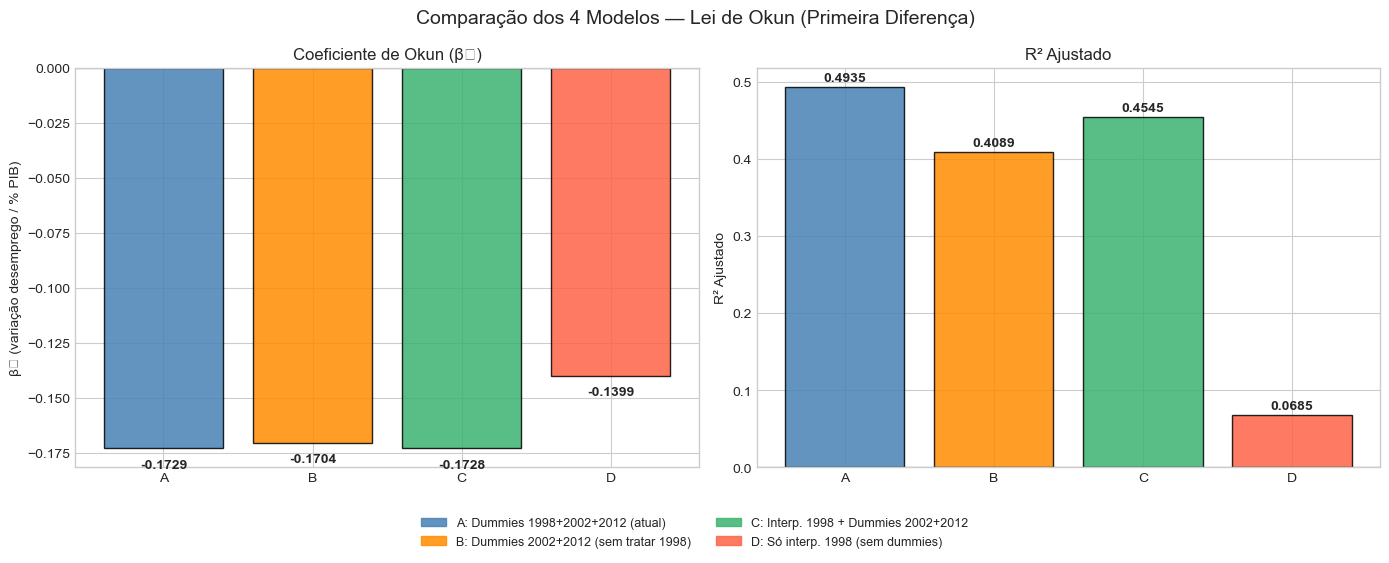


MODELO A: Dummies 1998+2002+2012 (atual)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     1291.
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.31e-76
Time:                        15:47:07   Log-Likelihood:                -103.41
No. Observations:                 114   AIC:                             216.8
Df Residuals:                     109   BIC:                             230.5
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [31]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# COMPARAÇÃO DOS 4 MODELOS — PRIMEIRA DIFERENÇA (CÉLULA INDEPENDENTE)
# ==============================================================================

# --- 1. CARREGAMENTO E PREPARAÇÃO BASE ---
pib_df = pd.read_pickle('../dados/pib_tratado.pkl')
desemprego_df = pd.read_pickle('../dados/desemprego_tratado.pkl')
if 'desemprego' in desemprego_df.columns:
    desemprego_df.rename(columns={'desemprego': 'u_t'}, inplace=True)

df = pib_df.join(desemprego_df, how='inner')
df = df[df.index <= '2024-12-31'].copy()
df['delta_u_t']          = df['u_t'].diff()
df['crescimento_pib']    = df['ln_pib'].diff() * 100
df['crescimento_pib_lag1'] = df['crescimento_pib'].shift(1)
df.dropna(inplace=True)

# --- 2. PULSE DUMMIES ---
df['d_1998_t1'] = (df.index == '1998-03-31').astype(float)
df['d_2002_t2'] = (df.index == '2002-06-30').astype(float)
df['d_2012_t1'] = (df.index == '2012-03-31').astype(float)

# --- 3. DATASET COM 1998-T1 INTERPOLADO ---
df_interp = df.copy()
df_interp.loc['1998-03-31', 'delta_u_t'] = np.nan
df_interp['delta_u_t'] = df_interp['delta_u_t'].interpolate(method='time')

# --- 4. FUNÇÃO DE DIAGNÓSTICO UNIFICADA ---
def rodar_modelo(nome, Y, X_vars, df_src, com_constante=True):
    X = sm.add_constant(df_src[X_vars]) if com_constante else df_src[X_vars]
    mod = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    jb_stat, jb_p, _, _ = jarque_bera(mod.resid)
    bg_p   = acorr_breusch_godfrey(mod, nlags=4)[1]
    wh_p   = het_white(mod.resid, mod.model.exog)[1]
    beta1  = mod.params.get('crescimento_pib_lag1', np.nan)
    beta1_p= mod.pvalues.get('crescimento_pib_lag1', np.nan)
    return {'nome': nome, 'mod': mod,
            'beta1': beta1, 'beta1_p': beta1_p,
            'r2adj': mod.rsquared_adj,
            'jb_p': jb_p, 'bg_p': bg_p, 'wh_p': wh_p}

resultados = []

# MODELO A — Pulse dummies nos 3 outliers (1998-T1, 2002-T2, 2012-T1) [MODELO ATUAL]
Y_A = df['delta_u_t']
resultados.append(rodar_modelo(
    'A: Dummies 1998+2002+2012 (atual)',
    Y_A, ['crescimento_pib_lag1','d_1998_t1','d_2002_t2','d_2012_t1'], df))

# MODELO B — Pulse dummies apenas nas transições metodológicas (2002-T2 e 2012-T1)
resultados.append(rodar_modelo(
    'B: Dummies 2002+2012 (sem tratar 1998)',
    Y_A, ['crescimento_pib_lag1','d_2002_t2','d_2012_t1'], df))

# MODELO C — Interpolação de 1998-T1 + pulse dummies nas transições (2002-T2 e 2012-T1)
Y_C = df_interp['delta_u_t']
resultados.append(rodar_modelo(
    'C: Interp. 1998 + Dummies 2002+2012',
    Y_C, ['crescimento_pib_lag1','d_2002_t2','d_2012_t1'], df_interp))

# MODELO D — Apenas interpolação de 1998-T1, sem nenhuma dummy
resultados.append(rodar_modelo(
    'D: Só interp. 1998 (sem dummies)',
    Y_C, ['crescimento_pib_lag1'], df_interp))

# --- 5. TABELA COMPARATIVA ---
sep = "="*80
print(sep)
print("TABELA COMPARATIVA — 4 MODELOS (Lei de Okun, Primeira Diferença, HAC)")
print(sep)
header = f"{'Modelo':<44} {'β₁':>8} {'p(β₁)':>7} {'R²Aj':>6}  {'JB':>8}  {'BG':>8}  {'White':>8}"
print(header)
print("-"*80)
for r in resultados:
    jb = f"{'✓' if r['jb_p']>0.05 else '✗'}{r['jb_p']:.3f}"
    bg = f"{'✓' if r['bg_p']>0.05 else '✗'}{r['bg_p']:.3f}"
    wh = f"{'✓' if r['wh_p']>0.05 else '✗'}{r['wh_p']:.3f}"
    print(f"{r['nome']:<44} {r['beta1']:>8.4f} {r['beta1_p']:>7.4f} {r['r2adj']:>6.4f}  {jb:>8}  {bg:>8}  {wh:>8}")
print(sep)
print("✓ = aprovado (p>0.05)  |  ✗ = reprovado  |  JB=Jarque-Bera  BG=Breusch-Godfrey")

# --- 6. GRÁFICO COMPARATIVO: β₁ e R² ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação dos 4 Modelos — Lei de Okun (Primeira Diferença)', fontsize=14)

nomes_curtos = ['A', 'B', 'C', 'D']
betas  = [r['beta1']  for r in resultados]
r2s    = [r['r2adj']  for r in resultados]
cores  = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato']
descricoes = [r['nome'].split(':')[1].strip() for r in resultados]

for ax, vals, titulo, ylabel in zip(
        axes,
        [betas, r2s],
        ['Coeficiente de Okun (β₁)', 'R² Ajustado'],
        ['β₁ (variação desemprego / % PIB)', 'R² Ajustado']):
    bars = ax.bar(nomes_curtos, vals, color=cores, alpha=0.85, edgecolor='black')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        offset = -0.005 if v < 0 else 0.003
        va = 'top' if v < 0 else 'bottom'
        ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                f'{v:.4f}', ha='center', va=va, fontsize=10, fontweight='bold')

# Legenda com descrições completas
legend_labels = [f"{n}: {d}" for n, d in zip(nomes_curtos, descricoes)]
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85) for c in cores]
fig.legend(handles, legend_labels, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.12), fontsize=9)

plt.tight_layout()
plt.savefig('../figuras/fase2_modelo1/fig_07_comparacao_4_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 7. SUMMARIES COMPLETOS ---
for r in resultados:
    print(f"\n{'='*65}\nMODELO {r['nome']}\n{'='*65}")
    print(r['mod'].summary())

MODELO A — Pulse Dummies 1998-T1 + 2002-T2 + 2012-T1
AIC = 216.8  |  BIC = 230.5  (vs. Modelo C: 214.8 / 225.8)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     1291.
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.31e-76
Time:                        15:47:07   Log-Likelihood:                -103.41
No. Observations:                 114   AIC:                             216.8
Df Residuals:                     109   BIC:                             230.5
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\2199102993.py:101: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\2199102993.py:102: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07a_modelo_A.png', dpi=150, bbox_inches='tight')
c:\Users\davyd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


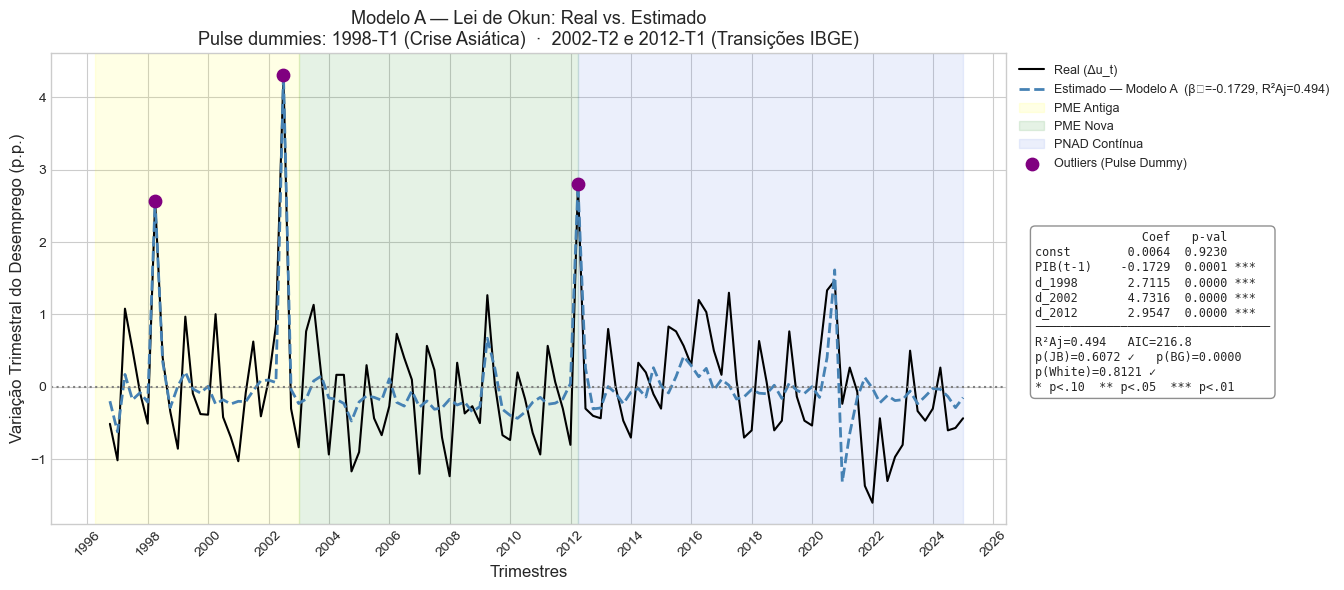

=> Figura salva: fig_07a_modelo_A.png


In [32]:
# ==============================================================================
# MODELO A — Pulse Dummies para os 3 outliers: 1998-T1, 2002-T2 e 2012-T1
# Δu_t = β₀ + β₁·PIB(t-1) + δ₁·d98 + δ₂·d02 + δ₃·d12 + ε_t
# RESULTADO: FINALISTA — passa JB, mas AIC/BIC ligeiramente piores que Modelo C
# ==============================================================================
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Dados e pulse dummies (os 3 outliers identificados na análise de resíduos)
df_A = df_model[['delta_u_t', 'crescimento_pib_lag1']].copy()
df_A['d_1998_t1'] = (df_A.index == '1998-03-31').astype(float)
df_A['d_2002_t2'] = (df_A.index == '2002-06-30').astype(float)
df_A['d_2012_t1'] = (df_A.index == '2012-03-31').astype(float)

Y_A = df_A['delta_u_t']
X_A = sm.add_constant(df_A[['crescimento_pib_lag1', 'd_1998_t1', 'd_2002_t2', 'd_2012_t1']])

# 2. Estimação com HAC
modelo_A = sm.OLS(Y_A, X_A).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# 3. Diagnósticos
jb_p_A = jarque_bera(modelo_A.resid)[1]
bg_p_A = acorr_breusch_godfrey(modelo_A, nlags=4)[1]
wh_p_A = het_white(modelo_A.resid, modelo_A.model.exog)[1]

print("=" * 70)
print("MODELO A — Pulse Dummies 1998-T1 + 2002-T2 + 2012-T1")
print(f"AIC = {modelo_A.aic:.1f}  |  BIC = {modelo_A.bic:.1f}  (vs. Modelo C: 214.8 / 225.8)")
print("=" * 70)
print(modelo_A.summary())

print("\n--- Diagnóstico dos Resíduos ---")
print(f"  Jarque-Bera    (Normalidade): p = {jb_p_A:.4f}  {'✓ OK' if jb_p_A > 0.05 else '✗ FALHOU'}")
print(f"  Breusch-Godfrey (Autocorr.): p = {bg_p_A:.4f}  {'✓ OK' if bg_p_A > 0.05 else '✗ FALHOU — HAC corrige as inferências'}")
print(f"  White           (Homoced.):  p = {wh_p_A:.4f}  {'✓ OK' if wh_p_A > 0.05 else '✗ FALHOU'}")

# 4. Coeficiente de Okun e Taxa Neutra
b0_A = modelo_A.params['const']
b1_A = modelo_A.params['crescimento_pib_lag1']
neutra_A    = -(b0_A / b1_A)
neutra_an_A = ((1 + neutra_A / 100) ** 4 - 1) * 100

print(f"\n--- Coeficiente de Okun ---")
print(f"  β₁ = {b1_A:.4f}  (p = {modelo_A.pvalues['crescimento_pib_lag1']:.4f})")
print(f"\n--- Taxa Neutra de Crescimento (Δu = 0) ---")
print(f"  Trimestral: {neutra_A:.4f}%  |  Anualizada: ≈ {neutra_an_A:.2f}% a.a.")
print(f"\n→ Finalista: passa JB e White. Preterido pelo Modelo C (AIC {modelo_A.aic:.1f} > 214.8)")

# 5. Gráfico Real vs Estimado
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_A.index, Y_A, color='black', linewidth=1.5, label='Real (Δu_t)')
ax.plot(df_A.index, modelo_A.fittedvalues,
        color='steelblue', linewidth=2, linestyle='--',
        label=f'Estimado — Modelo A  (β₁={b1_A:.4f}, R²Aj={modelo_A.rsquared_adj:.3f})')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)

ax.axvspan('1996-03-31', '2002-12-31', color='yellow',    alpha=0.10, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green',     alpha=0.10, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='royalblue', alpha=0.10, label='PNAD Contínua')

outlier_dates = pd.to_datetime(['1998-03-31', '2002-06-30', '2012-03-31'])
ax.scatter(outlier_dates, Y_A.loc[outlier_dates],
           color='purple', s=80, zorder=5, label='Outliers (Pulse Dummy)')

ax.set_title('Modelo A — Lei de Okun: Real vs. Estimado\n'
             'Pulse dummies: 1998-T1 (Crise Asiática)  ·  2002-T2 e 2012-T1 (Transições IBGE)', fontsize=13)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1), fontsize=9)

# Caixa com p-valores de todos os coeficientes (direita, fora dos eixos)
_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'crescimento_pib_lag1': 'PIB(t-1)',
          'd_1998_t1': 'd_1998', 'd_2002_t2': 'd_2002', 'd_2012_t1': 'd_2012'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in modelo_A.params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{modelo_A.params[_n]:>8.4f}  {modelo_A.pvalues[_n]:>6.4f} {_stars(modelo_A.pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={modelo_A.rsquared_adj:.3f}   AIC={modelo_A.aic:.1f}",
    f"p(JB)={jb_p_A:.4f} {'✓' if jb_p_A > 0.05 else '✗'}   p(BG)={bg_p_A:.4f}",
    f"p(White)={wh_p_A:.4f} {'✓' if wh_p_A > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
pval_box_A = '\n'.join(_lines)
ax.annotate(pval_box_A, xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase2_modelo1/fig_07a_modelo_A.png', dpi=150, bbox_inches='tight')
plt.show()
print("=> Figura salva: fig_07a_modelo_A.png")

MODELO B — Pulse Dummies 2002-T2 + 2012-T1 (1998-T1 sem tratamento)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     1275.
Date:                Sun, 10 May 2026   Prob (F-statistic):           8.25e-77
Time:                        15:47:08   Log-Likelihood:                -112.74
No. Observations:                 114   AIC:                             233.5
Df Residuals:                     110   BIC:                             244.4
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\3102654163.py:102: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\3102654163.py:102: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\3102654163.py:103: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07b_modelo_B.png', dpi=150, bbox_inches='tight')
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\3102654163.py:103: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07b_model

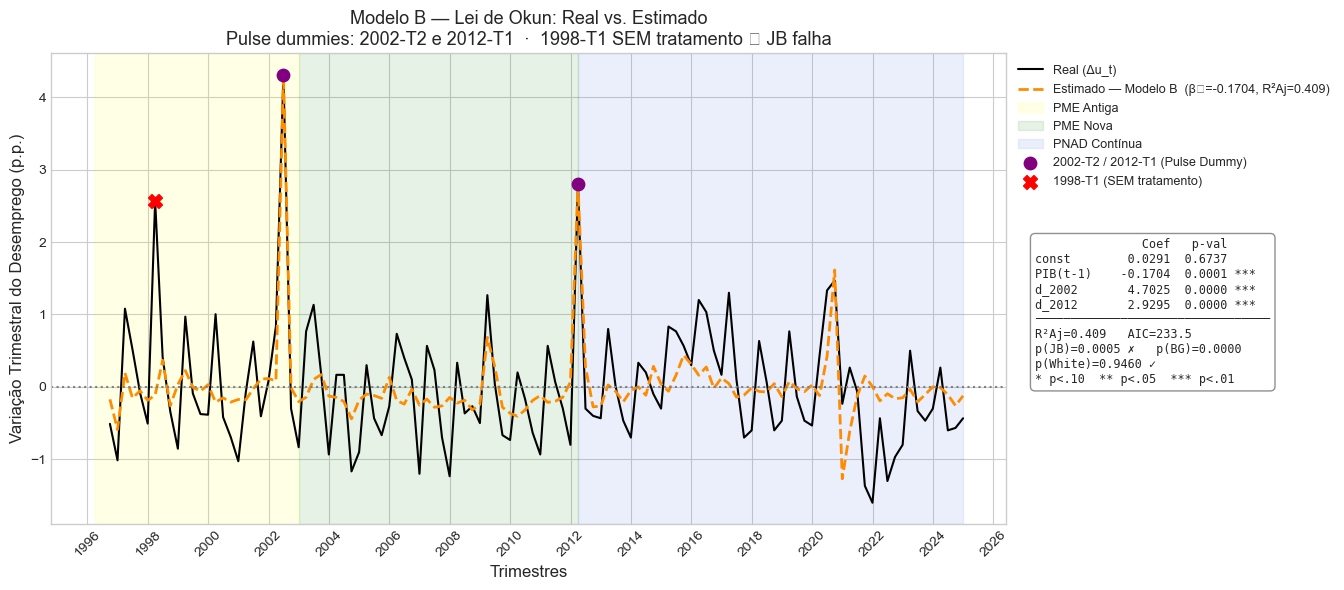

=> Figura salva: fig_07b_modelo_B.png


In [33]:
# ==============================================================================
# MODELO B — Pulse Dummies apenas 2002-T2 e 2012-T1 (sem tratar 1998-T1)
# Δu_t = β₀ + β₁·PIB(t-1) + δ₂·d02 + δ₃·d12 + ε_t
# RESULTADO: DESCARTADO — falha no Jarque-Bera (1998-T1 intratado distorce resíduos)
# ==============================================================================
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Dados e dummies (sem tratar 1998-T1)
df_B = df_model[['delta_u_t', 'crescimento_pib_lag1']].copy()
df_B['d_2002_t2'] = (df_B.index == '2002-06-30').astype(float)
df_B['d_2012_t1'] = (df_B.index == '2012-03-31').astype(float)

Y_B = df_B['delta_u_t']
X_B = sm.add_constant(df_B[['crescimento_pib_lag1', 'd_2002_t2', 'd_2012_t1']])

# 2. Estimação com HAC
modelo_B = sm.OLS(Y_B, X_B).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# 3. Diagnósticos
jb_p_B = jarque_bera(modelo_B.resid)[1]
bg_p_B = acorr_breusch_godfrey(modelo_B, nlags=4)[1]
wh_p_B = het_white(modelo_B.resid, modelo_B.model.exog)[1]

print("=" * 70)
print("MODELO B — Pulse Dummies 2002-T2 + 2012-T1 (1998-T1 sem tratamento)")
print("=" * 70)
print(modelo_B.summary())

print("\n--- Diagnóstico dos Resíduos ---")
print(f"  Jarque-Bera    (Normalidade): p = {jb_p_B:.4f}  {'✓ OK' if jb_p_B > 0.05 else '✗ FALHOU — 1998-T1 não tratado distorce distribuição dos resíduos'}")
print(f"  Breusch-Godfrey (Autocorr.): p = {bg_p_B:.4f}  {'✓ OK' if bg_p_B > 0.05 else '✗ FALHOU — HAC corrige as inferências'}")
print(f"  White           (Homoced.):  p = {wh_p_B:.4f}  {'✓ OK' if wh_p_B > 0.05 else '✗ FALHOU'}")

# 4. Coeficiente de Okun e Taxa Neutra
b0_B = modelo_B.params['const']
b1_B = modelo_B.params['crescimento_pib_lag1']
neutra_B    = -(b0_B / b1_B)
neutra_an_B = ((1 + neutra_B / 100) ** 4 - 1) * 100

print(f"\n--- Coeficiente de Okun ---")
print(f"  β₁ = {b1_B:.4f}  (p = {modelo_B.pvalues['crescimento_pib_lag1']:.4f})")
print(f"\n--- Taxa Neutra de Crescimento (Δu = 0) ---")
print(f"  Trimestral: {neutra_B:.4f}%  |  Anualizada: ≈ {neutra_an_B:.2f}% a.a.")
print(f"\n⚠ MODELO DESCARTADO: falha no Jarque-Bera (JB p={jb_p_B:.3f} < 0.05).")

# 5. Gráfico Real vs Estimado
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_B.index, Y_B, color='black', linewidth=1.5, label='Real (Δu_t)')
ax.plot(df_B.index, modelo_B.fittedvalues,
        color='darkorange', linewidth=2, linestyle='--',
        label=f'Estimado — Modelo B  (β₁={b1_B:.4f}, R²Aj={modelo_B.rsquared_adj:.3f})')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)

ax.axvspan('1996-03-31', '2002-12-31', color='yellow',    alpha=0.10, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green',     alpha=0.10, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='royalblue', alpha=0.10, label='PNAD Contínua')

ax.scatter(pd.to_datetime(['2002-06-30', '2012-03-31']),
           Y_B.loc[['2002-06-30', '2012-03-31']], color='purple', s=80, zorder=5,
           label='2002-T2 / 2012-T1 (Pulse Dummy)')
ax.scatter(pd.to_datetime(['1998-03-31']),
           Y_B.loc[['1998-03-31']], color='red', s=100, marker='X', zorder=5,
           label='1998-T1 (SEM tratamento)')

ax.set_title('Modelo B — Lei de Okun: Real vs. Estimado\n'
             'Pulse dummies: 2002-T2 e 2012-T1  ·  1998-T1 SEM tratamento ⚠ JB falha', fontsize=13)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1), fontsize=9)

# Caixa com p-valores de todos os coeficientes (direita, fora dos eixos)
_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'crescimento_pib_lag1': 'PIB(t-1)',
          'd_2002_t2': 'd_2002', 'd_2012_t1': 'd_2012'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in modelo_B.params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{modelo_B.params[_n]:>8.4f}  {modelo_B.pvalues[_n]:>6.4f} {_stars(modelo_B.pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={modelo_B.rsquared_adj:.3f}   AIC={modelo_B.aic:.1f}",
    f"p(JB)={jb_p_B:.4f} {'✓' if jb_p_B > 0.05 else '✗'}   p(BG)={bg_p_B:.4f}",
    f"p(White)={wh_p_B:.4f} {'✓' if wh_p_B > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
pval_box_B = '\n'.join(_lines)
ax.annotate(pval_box_B, xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase2_modelo1/fig_07b_modelo_B.png', dpi=150, bbox_inches='tight')
plt.show()
print("=> Figura salva: fig_07b_modelo_B.png")

MODELO C ★  Interpolação 1998-T1 + Pulse Dummies 2002-T2 + 2012-T1
AIC = 214.8  |  BIC = 225.8  (menor entre os modelos aprovados)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     1488.
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.29e-80
Time:                        15:48:51   Log-Likelihood:                -103.42
No. Observations:                 114   AIC:                             214.8
Df Residuals:                     110   BIC:                             225.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025   

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1666885996.py:112: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1666885996.py:112: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1666885996.py:113: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07c_modelo_C.png', dpi=150, bbox_inches='tight')
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1666885996.py:113: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07c_modelo_C.

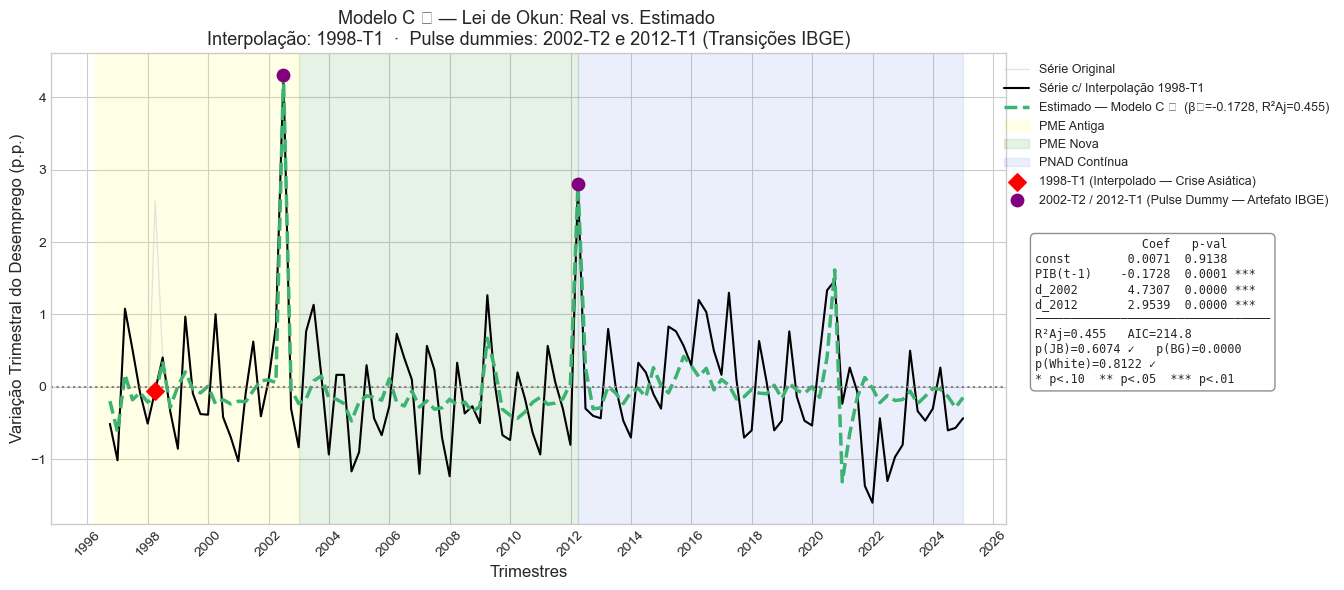

=> Figuras salvas: fig_07c_modelo_C.png  e  fig_08_real_vs_estimado_modelo_final.png


In [37]:
# ==============================================================================
# MODELO C ★ — Interpolação 1998-T1 + Pulse Dummies 2002-T2 e 2012-T1
# Δu_t = β₀ + β₁·PIB(t-1) + δ₂·d02 + δ₃·d12 + ε_t  |  1998-T1 interpolado
# RESULTADO: MODELO FINAL SELECIONADO — melhor AIC/BIC, passa JB, coerente economicamente
# ==============================================================================
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# 1. Dados com interpolação de 1998-T1 e dummies para artefatos metodológicos
df_C = df_model[['delta_u_t', 'crescimento_pib_lag1']].copy()
df_C.loc['1998-03-31', 'delta_u_t'] = np.nan
df_C['delta_u_t'] = df_C['delta_u_t'].interpolate(method='time')

df_C['d_2002_t2'] = (df_C.index == '2002-06-30').astype(float)
df_C['d_2012_t1'] = (df_C.index == '2012-03-31').astype(float)

Y_C = df_C['delta_u_t']
X_C = sm.add_constant(df_C[['crescimento_pib_lag1', 'd_2002_t2', 'd_2012_t1']])

# 2. Estimação com HAC
modelo_C = sm.OLS(Y_C, X_C).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# 3. Diagnósticos
jb_p_C = jarque_bera(modelo_C.resid)[1]
bg_p_C = acorr_breusch_godfrey(modelo_C, nlags=4)[1]
wh_p_C = het_white(modelo_C.resid, modelo_C.model.exog)[1]

print("=" * 70)
print("MODELO C ★  Interpolação 1998-T1 + Pulse Dummies 2002-T2 + 2012-T1")
print(f"AIC = {modelo_C.aic:.1f}  |  BIC = {modelo_C.bic:.1f}  (menor entre os modelos aprovados)")
print("=" * 70)
print(modelo_C.summary())

print("\n--- Diagnóstico dos Resíduos ---")
print(f"  Jarque-Bera    (Normalidade): p = {jb_p_C:.4f}  {'✓ OK' if jb_p_C > 0.05 else '✗ FALHOU'}")
print(f"  Breusch-Godfrey (Autocorr.): p = {bg_p_C:.4f}  {'✓ OK' if bg_p_C > 0.05 else '✗ FALHOU — HAC corrige as inferências'}")
print(f"  White           (Homoced.):  p = {wh_p_C:.4f}  {'✓ OK' if wh_p_C > 0.05 else '✗ FALHOU'}")

# 4. Coeficiente de Okun e Taxa Neutra
b0_C = modelo_C.params['const']
b1_C = modelo_C.params['crescimento_pib_lag1']
neutra_C    = -(b0_C / b1_C)
neutra_an_C = ((1 + neutra_C / 100) ** 4 - 1) * 100

print(f"\n--- Coeficiente de Okun ---")
print(f"  β₁ = {b1_C:.4f}  (p = {modelo_C.pvalues['crescimento_pib_lag1']:.4f})")
print(f"\n--- Taxa Neutra de Crescimento (Δu = 0) ---")
print(f"  = -(β₀/β₁) = -({b0_C:.4f}/{b1_C:.4f})")
print(f"  Trimestral: {neutra_C:.4f}%  |  Anualizada: ≈ {neutra_an_C:.2f}% a.a.")
print(f"\n★ MODELO FINAL SELECIONADO: menor AIC ({modelo_C.aic:.1f}) e BIC ({modelo_C.bic:.1f}),")
print(f"  passa JB (p={jb_p_C:.3f}) e White (p={wh_p_C:.3f}), tratamento economicamente coerente.")

# 5. Gráfico Real vs Estimado
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_model.index, df_model['delta_u_t'],
        color='lightgray', linewidth=1, alpha=0.6, label='Série Original')
ax.plot(df_C.index, Y_C,
        color='black', linewidth=1.5, label='Série c/ Interpolação 1998-T1')
ax.plot(df_C.index, modelo_C.fittedvalues,
        color='mediumseagreen', linewidth=2.5, linestyle='--',
        label=f'Estimado — Modelo C ★  (β₁={b1_C:.4f}, R²Aj={modelo_C.rsquared_adj:.3f})')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)

ax.axvspan('1996-03-31', '2002-12-31', color='yellow',    alpha=0.10, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green',     alpha=0.10, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='royalblue', alpha=0.10, label='PNAD Contínua')

ax.scatter(pd.to_datetime(['1998-03-31']),
           Y_C.loc[['1998-03-31']], color='red', s=80, zorder=5, marker='D',
           label='1998-T1 (Interpolado — Crise Asiática)')
ax.scatter(pd.to_datetime(['2002-06-30', '2012-03-31']),
           Y_C.loc[['2002-06-30', '2012-03-31']], color='purple', s=80, zorder=5,
           label='2002-T2 / 2012-T1 (Pulse Dummy — Artefato IBGE)')

ax.set_title('Modelo C ★ — Lei de Okun: Real vs. Estimado \n'
             'Interpolação: 1998-T1  ·  Pulse dummies: 2002-T2 e 2012-T1 (Transições IBGE)', fontsize=13)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1), fontsize=9)

# Caixa com p-valores de todos os coeficientes (direita, fora dos eixos)
_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'crescimento_pib_lag1': 'PIB(t-1)',
          'd_2002_t2': 'd_2002', 'd_2012_t1': 'd_2012'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in modelo_C.params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{modelo_C.params[_n]:>8.4f}  {modelo_C.pvalues[_n]:>6.4f} {_stars(modelo_C.pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={modelo_C.rsquared_adj:.3f}   AIC={modelo_C.aic:.1f}",
    f"p(JB)={jb_p_C:.4f} {'✓' if jb_p_C > 0.05 else '✗'}   p(BG)={bg_p_C:.4f}",
    f"p(White)={wh_p_C:.4f} {'✓' if wh_p_C > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
pval_box_C = '\n'.join(_lines)
ax.annotate(pval_box_C, xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase2_modelo1/fig_07c_modelo_C.png', dpi=150, bbox_inches='tight')
plt.savefig('../figuras/fase2_modelo1/fig_08_real_vs_estimado_modelo_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("=> Figuras salvas: fig_07c_modelo_C.png  e  fig_08_real_vs_estimado_modelo_final.png")

DIAGNÓSTICO FINAL — MODELO C (Resíduos)
  Jarque-Bera   p = 0.6074  ✓ Normais
  Breusch-Godfrey p = 0.0000  ✗ Autocorr. (HAC corrige)
  White           p = 0.8122  ✓ Homocedásticos
  Skewness = 0.0386  |  Kurtosis = 2.5483


C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\3980623144.py:60: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_09_residuos_diagnostico.png', dpi=150, bbox_inches='tight')
c:\Users\davyd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


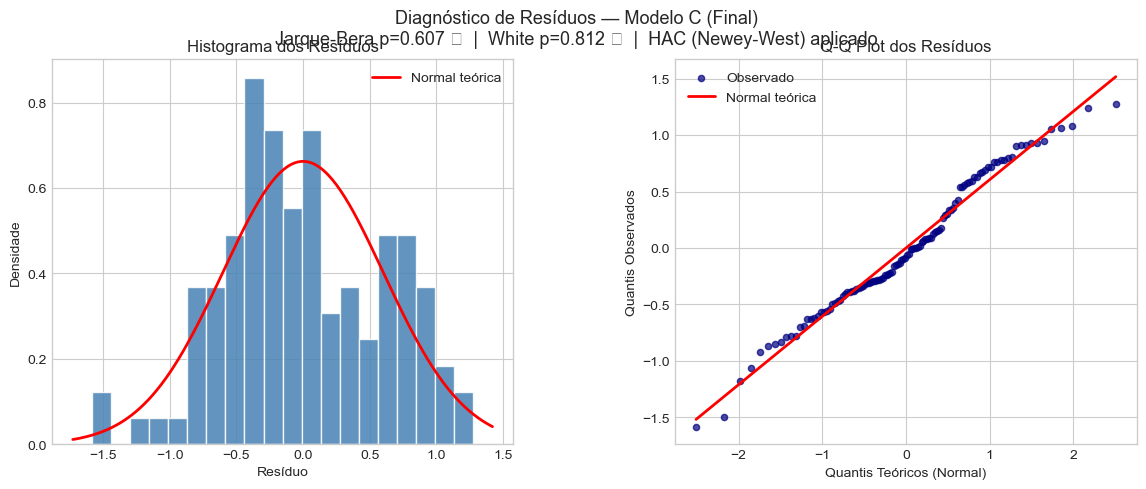

=> Figura salva: fig_09_residuos_diagnostico.png


In [35]:
# ==============================================================================
# DIAGNÓSTICO DE RESÍDUOS — MODELO FINAL (MODELO C)
# Gera: histograma + Q-Q plot dos resíduos → fig_09_residuos_diagnostico.png
# Requer: modelo_C definido na célula anterior
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import numpy as np
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey

residuos = modelo_C.resid

# --- Diagnósticos numéricos ---
jb_stat, jb_p, skew, kurt = jarque_bera(residuos)
bg_p  = acorr_breusch_godfrey(modelo_C, nlags=4)[1]
wh_p  = het_white(residuos, modelo_C.model.exog)[1]

print("=" * 55)
print("DIAGNÓSTICO FINAL — MODELO C (Resíduos)")
print("=" * 55)
print(f"  Jarque-Bera   p = {jb_p:.4f}  {'✓ Normais' if jb_p > 0.05 else '✗ Não-normais'}")
print(f"  Breusch-Godfrey p = {bg_p:.4f}  {'✓ Sem autocorr.' if bg_p > 0.05 else '✗ Autocorr. (HAC corrige)'}")
print(f"  White           p = {wh_p:.4f}  {'✓ Homocedásticos' if wh_p > 0.05 else '✗ Heterocedásticos'}")
print(f"  Skewness = {skew:.4f}  |  Kurtosis = {kurt:.4f}")

# --- Gráfico: Histograma + Q-Q Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 5))
fig.suptitle('Diagnóstico de Resíduos — Modelo C (Final)\n'
             f'Jarque-Bera p={jb_p:.3f} ✓  |  White p={wh_p:.3f} ✓  |  HAC (Newey-West) aplicado',
             fontsize=13)

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# Histograma
ax1 = fig.add_subplot(gs[0])
ax1.hist(residuos, bins=20, color='steelblue', edgecolor='white', alpha=0.85, density=True)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 200)
mu, sigma = residuos.mean(), residuos.std()
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
ax1.set_title('Histograma dos Resíduos', fontsize=12)
ax1.set_xlabel('Resíduo')
ax1.set_ylabel('Densidade')
ax1.legend(fontsize=10)

# Q-Q Plot
ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
ax2.scatter(osm, osr, color='navy', s=20, alpha=0.7, label='Observado')
line_x = np.array([min(osm), max(osm)])
ax2.plot(line_x, slope * line_x + intercept, 'r-', linewidth=2, label='Normal teórica')
ax2.set_title('Q-Q Plot dos Resíduos', fontsize=12)
ax2.set_xlabel('Quantis Teóricos (Normal)')
ax2.set_ylabel('Quantis Observados')
ax2.legend(fontsize=10)

plt.savefig('../figuras/fase2_modelo1/fig_09_residuos_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()
print("=> Figura salva: fig_09_residuos_diagnostico.png")

MODELO D — Apenas Interpolação 1998-T1 (2002-T2 e 2012-T1 sem tratamento)
                            OLS Regression Results                            
Dep. Variable:              delta_u_t   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     10.39
Date:                Sun, 10 May 2026   Prob (F-statistic):            0.00166
Time:                        15:47:12   Log-Likelihood:                -134.95
No. Observations:                 114   AIC:                             273.9
Df Residuals:                     112   BIC:                             279.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1640716240.py:105: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1640716240.py:105: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1640716240.py:106: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07d_modelo_D.png', dpi=150, bbox_inches='tight')
C:\Users\davyd\AppData\Local\Temp\ipykernel_15468\1640716240.py:106: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('../figuras/fase2_modelo1/fig_07d_modelo_D.png', dpi=150, bbox_inches='tight')
c:\Users\davyd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\davyd\anacond

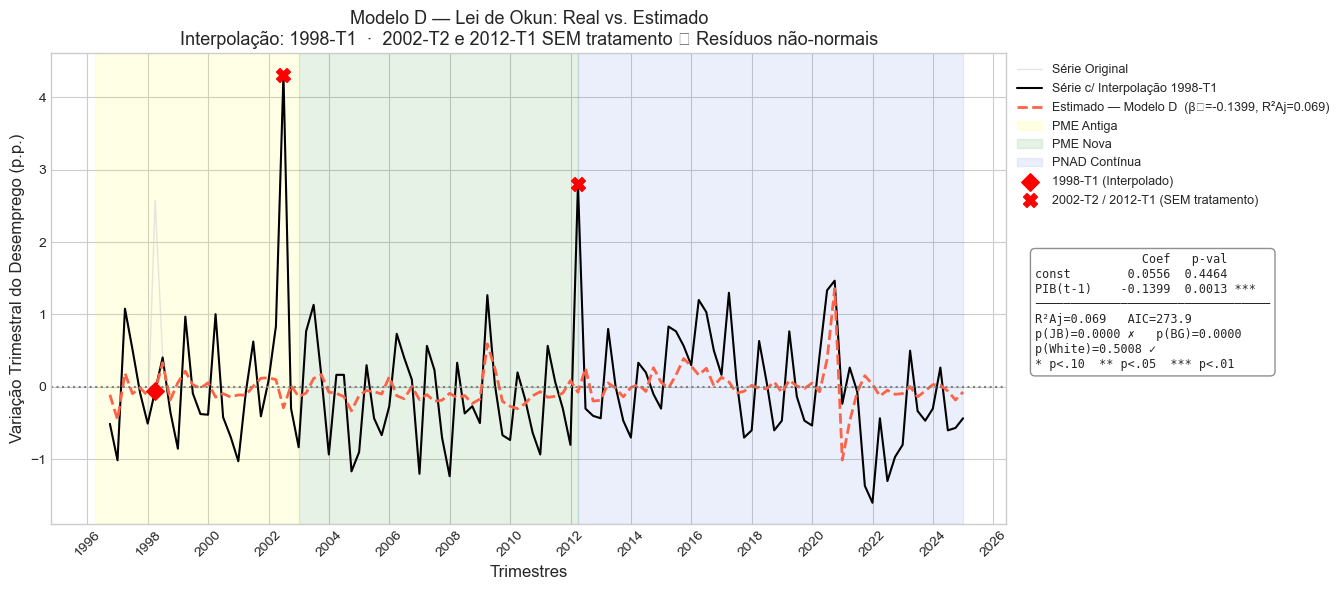

=> Figura salva: fig_07d_modelo_D.png


In [36]:
# ==============================================================================
# MODELO D — Apenas interpolação de 1998-T1 (sem dummies para 2002-T2 e 2012-T1)
# Δu_t = β₀ + β₁·PIB(t-1) + ε_t   |  1998-T1 interpolado; 2002-T2, 2012-T1 sem tratamento
# RESULTADO: DESCARTADO — falha grave no Jarque-Bera (artefatos IBGE distorcem resíduos)
# ==============================================================================
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# 1. Dados com interpolação de 1998-T1 (choque econômico real)
df_D = df_model[['delta_u_t', 'crescimento_pib_lag1']].copy()
df_D.loc['1998-03-31', 'delta_u_t'] = np.nan
df_D['delta_u_t'] = df_D['delta_u_t'].interpolate(method='time')

Y_D = df_D['delta_u_t']
X_D = sm.add_constant(df_D['crescimento_pib_lag1'])

# 2. Estimação com HAC
modelo_D = sm.OLS(Y_D, X_D).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# 3. Diagnósticos
jb_p_D = jarque_bera(modelo_D.resid)[1]
bg_p_D = acorr_breusch_godfrey(modelo_D, nlags=4)[1]
wh_p_D = het_white(modelo_D.resid, modelo_D.model.exog)[1]

print("=" * 70)
print("MODELO D — Apenas Interpolação 1998-T1 (2002-T2 e 2012-T1 sem tratamento)")
print("=" * 70)
print(modelo_D.summary())

print("\n--- Diagnóstico dos Resíduos ---")
print(f"  Jarque-Bera    (Normalidade): p = {jb_p_D:.4f}  {'✓ OK' if jb_p_D > 0.05 else '✗ FALHOU — artefatos 2002 e 2012 distorcem fortemente os resíduos'}")
print(f"  Breusch-Godfrey (Autocorr.): p = {bg_p_D:.4f}  {'✓ OK' if bg_p_D > 0.05 else '✗ FALHOU — HAC corrige as inferências'}")
print(f"  White           (Homoced.):  p = {wh_p_D:.4f}  {'✓ OK' if wh_p_D > 0.05 else '✗ FALHOU'}")

# 4. Coeficiente de Okun e Taxa Neutra
b0_D = modelo_D.params['const']
b1_D = modelo_D.params['crescimento_pib_lag1']
neutra_D    = -(b0_D / b1_D)
neutra_an_D = ((1 + neutra_D / 100) ** 4 - 1) * 100

print(f"\n--- Coeficiente de Okun ---")
print(f"  β₁ = {b1_D:.4f}  (p = {modelo_D.pvalues['crescimento_pib_lag1']:.4f})")
print(f"\n--- Taxa Neutra de Crescimento (Δu = 0) ---")
print(f"  Trimestral: {neutra_D:.4f}%  |  Anualizada: ≈ {neutra_an_D:.2f}% a.a.")
print(f"\n⚠ MODELO DESCARTADO: falha grave em Jarque-Bera (JB p < 0.001) e R²Aj = {modelo_D.rsquared_adj:.3f}.")

# 5. Gráfico Real vs Estimado
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_model.index, df_model['delta_u_t'],
        color='lightgray', linewidth=1, alpha=0.6, label='Série Original')
ax.plot(df_D.index, Y_D,
        color='black', linewidth=1.5, label='Série c/ Interpolação 1998-T1')
ax.plot(df_D.index, modelo_D.fittedvalues,
        color='tomato', linewidth=2, linestyle='--',
        label=f'Estimado — Modelo D  (β₁={b1_D:.4f}, R²Aj={modelo_D.rsquared_adj:.3f})')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)

ax.axvspan('1996-03-31', '2002-12-31', color='yellow',    alpha=0.10, label='PME Antiga')
ax.axvspan('2003-01-01', '2012-03-31', color='green',     alpha=0.10, label='PME Nova')
ax.axvspan('2012-04-01', '2024-12-31', color='royalblue', alpha=0.10, label='PNAD Contínua')

ax.scatter(pd.to_datetime(['1998-03-31']),
           Y_D.loc[['1998-03-31']], color='red', s=80, zorder=5, marker='D',
           label='1998-T1 (Interpolado)')
artefatos = pd.to_datetime(['2002-06-30', '2012-03-31'])
ax.scatter(artefatos, Y_D.loc[artefatos],
           color='red', s=100, marker='X', zorder=5, label='2002-T2 / 2012-T1 (SEM tratamento)')

ax.set_title('Modelo D — Lei de Okun: Real vs. Estimado\n'
             'Interpolação: 1998-T1  ·  2002-T2 e 2012-T1 SEM tratamento ⚠ Resíduos não-normais', fontsize=13)
ax.set_ylabel('Variação Trimestral do Desemprego (p.p.)', fontsize=12)
ax.set_xlabel('Trimestres', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1), fontsize=9)

# Caixa com p-valores de todos os coeficientes (direita, fora dos eixos)
_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'crescimento_pib_lag1': 'PIB(t-1)'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in modelo_D.params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{modelo_D.params[_n]:>8.4f}  {modelo_D.pvalues[_n]:>6.4f} {_stars(modelo_D.pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={modelo_D.rsquared_adj:.3f}   AIC={modelo_D.aic:.1f}",
    f"p(JB)={jb_p_D:.4f} {'✓' if jb_p_D > 0.05 else '✗'}   p(BG)={bg_p_D:.4f}",
    f"p(White)={wh_p_D:.4f} {'✓' if wh_p_D > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
pval_box_D = '\n'.join(_lines)
ax.annotate(pval_box_D, xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase2_modelo1/fig_07d_modelo_D.png', dpi=150, bbox_inches='tight')
plt.show()
print("=> Figura salva: fig_07d_modelo_D.png")